In [ ]:
import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[2])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)
from sigpy import mri
import scipy
import pickle
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import seaborn as sns
import sigpy as sp
import cupy as cp
import numpy as np
from sigpy.mri.app import L1WaveletRecon


## My files
import save_data_helpers
import recon_functions
import recon_plot_helpers
from gating_functions import golden_angle_coords_3d
import sigpy.plot as pl

### Load gated data

In [2]:
idx, resp_trimmed, data_bins, spoke_bins, index_bins = save_data_helpers.load_gate_outputs_pickle('/home/lilianae/projects/naf_clean/load_data_clean/subject2_mid0082/gates_dense_amp_512.pkl')
print(f'data_bins[0].shape = {data_bins[0].shape}')
print(f'spoke_bins[0].shape = {spoke_bins[0].shape}')

ksp_gate0 = data_bins[0]
coords_gate0 = spoke_bins[0]
ncoils, npts, nsamples = data_bins[0].shape
img_shape = (58, nsamples, nsamples)
print(f'img_shape = {img_shape}')

espirit_mps_gate0 = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/coils/subject2_mid0082/espirit_mps_full_res_ksp_512_ungated.pkl')
print(f'espirit_mps_gate0.shape = {espirit_mps_gate0.shape}')

dcf_ksp_5gates = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/recons/subject2_mid0082/pkl_files_512/dcf_ksp_dense_512_5gates.pkl')
dcf_ksp_gate0 = dcf_ksp_5gates[0]
print(f'dcf_ksp_gate0.shape = {dcf_ksp_gate0.shape}')

ksp_gate0_with_dcf = ksp_gate0 * dcf_ksp_gate0[None,...]
print(f'ksp_gate0_with_dcf.shape = {ksp_gate0_with_dcf.shape}')

Loaded /home/lilianae/projects/naf_clean/load_data_clean/subject2_mid0082/gates_dense_amp_512.pkl
  idx shape: (113116,)
  signal_trimmed shape: (113116,)
  data_bins: 5 elements
  spoke_bins: 5 elements
  index_bins: 5 elements
data_bins[0].shape = (15, 22623, 512)
spoke_bins[0].shape = (22623, 512, 3)
img_shape = (58, 512, 512)
espirit_mps_gate0.shape = (15, 58, 512, 512)
dcf_ksp_gate0.shape = (22623, 512)
ksp_gate0_with_dcf.shape = (15, 22623, 512)


### Helper function: Check data ranges

In [18]:
def check_data(data):
    """Print data ranges and dtype"""
    print(f"Step X - Shape: {data.shape}")
    print(f"  Real range: [{np.min(np.real(data))}, {np.max(np.real(data))}]")
    print(f"  Imag range: [{np.min(np.imag(data))}, {np.max(np.imag(data))}]")
    print(f"  Magnitude range: [{np.min(np.abs(data))}, {np.max(np.abs(data))}]")
    print(f"  Dtype: {data.dtype}")
    print(f"  Any NaN: {np.any(np.isnan(data))}, Any Inf: {np.any(np.isinf(data))}")


### 1. Sense/Multiply Linop

In [4]:
ncoils, nz, ny, nx = espirit_mps_gate0.shape

S = sp.linop.Multiply((nz, ny, nx), espirit_mps_gate0)

print(f'Input shape of Sense adjoint operator = {S.H.ishape}')
print(f'Output shape of Sense adjoint operator = {S.H.oshape}')

Input shape of Sense adjoint operator = [15, 58, 512, 512]
Output shape of Sense adjoint operator = [58, 512, 512]


### 2. NUFFT Linop

In [5]:
## Creat NUFFT Operator. 
## We will be applying adjoint:
## First argument is desired output shape, second arg is non-cartesian coordinate system

F = sp.linop.NUFFT((ncoils, nz, ny, nx), coord=coords_gate0)

print(f'Input shape of NUFFTAdjoint operator = {F.H.ishape}')
print(f'Output shape of NUFFTAdjoint operator = {F.H.oshape}')

Input shape of NUFFTAdjoint operator = [15, 22623, 512]
Output shape of NUFFTAdjoint operator = [15, 58, 512, 512]


NUFFT images

In [6]:
nufft_images = F.H * ksp_gate0_with_dcf
print(f'nufft_images.shape = {nufft_images.shape}')
# Normalize first
# CORRECT - normalize each coil independently
nufft_images_norm = np.zeros_like(nufft_images)
for coil in range(nufft_images.shape[0]):  
    img = np.abs(nufft_images[coil])
    nufft_images_norm[coil] = (img - np.min(img)) / (np.max(img) - np.min(img))

nufft_images.shape = (15, 58, 512, 512)


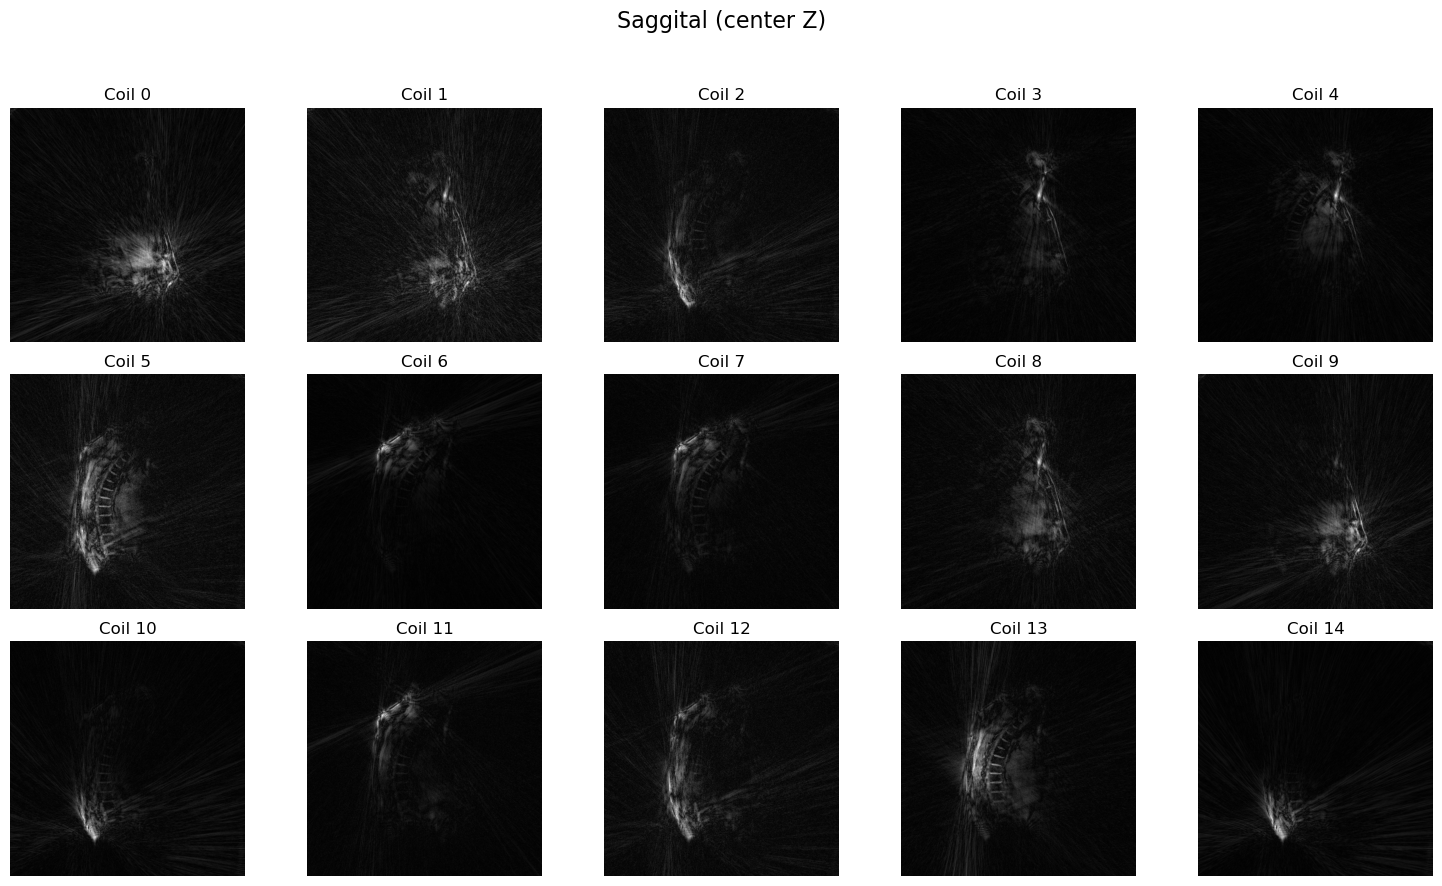

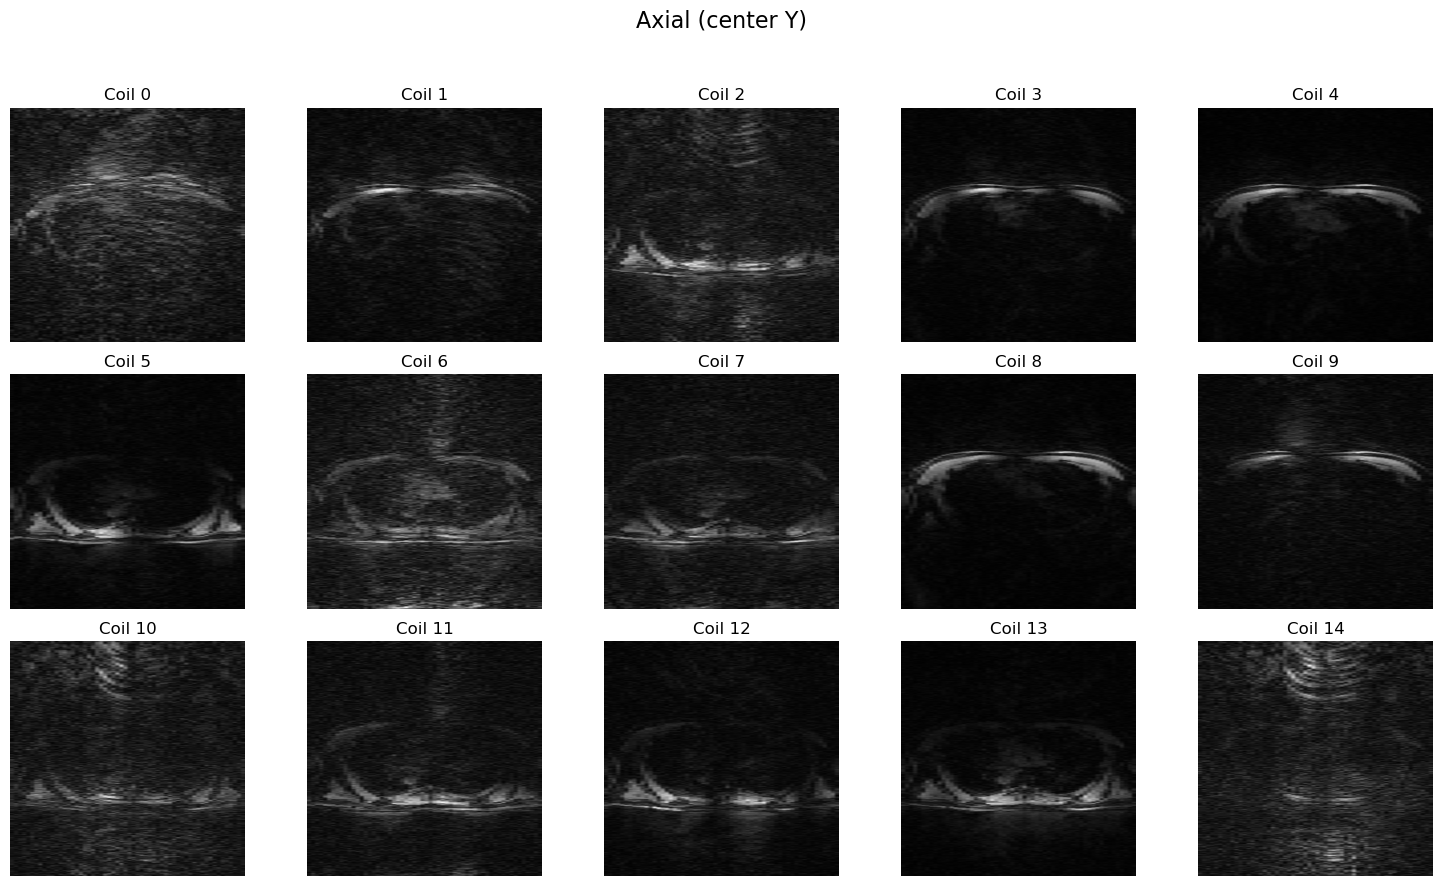

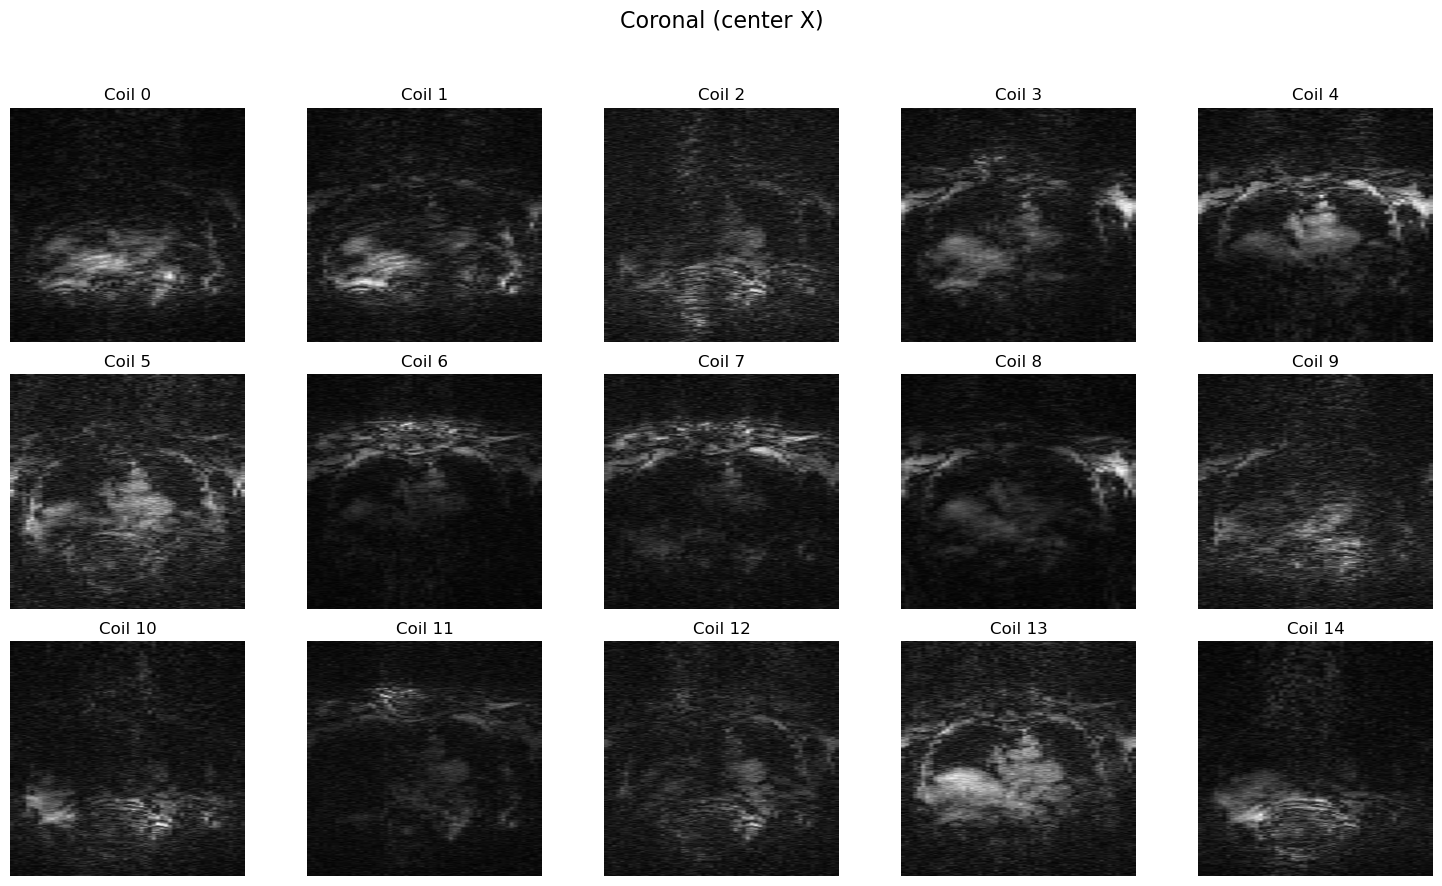

In [7]:
recon_plot_helpers.plot_center_slices(nufft_images_norm)

### SENSE + NUFFT Linop

In [8]:
nufft_and_sense_images = S.H * nufft_images_norm

print(f'nufft_and_sense_images.shape = {nufft_and_sense_images.shape}')

img = np.abs(nufft_and_sense_images)
nufft_sense_norm =  (img - np.min(img)) / (np.max(img) - np.min(img))

nufft_and_sense_images.shape = (58, 512, 512)


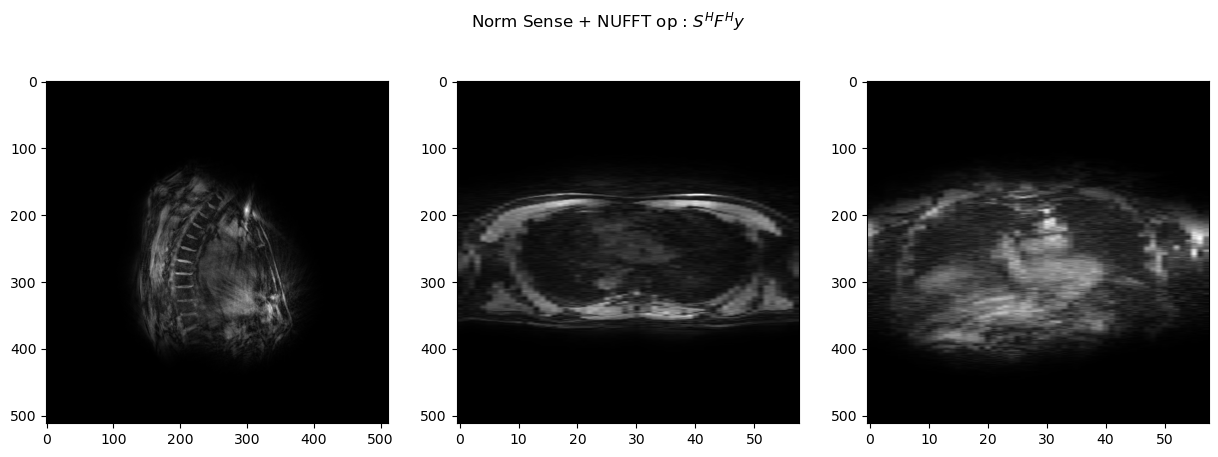

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [9]:
recon_plot_helpers.plot_recons_all_axes(np.abs(nufft_sense_norm), title="Norm Sense + NUFFT op : $S^H F^H y$")

### W Linop

/home/lilianae/mambaforge/envs/jointrecon_env_backup_new/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 8 is too high: all coefficients will experience boundary effects.
  warnings.warn(


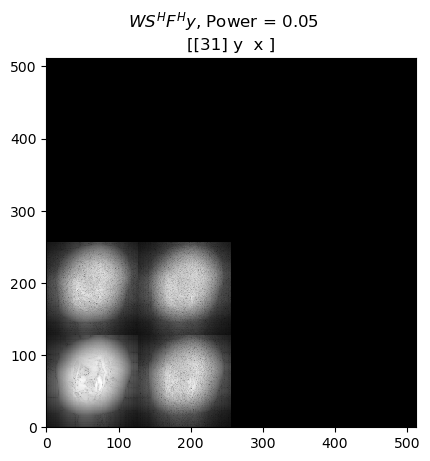

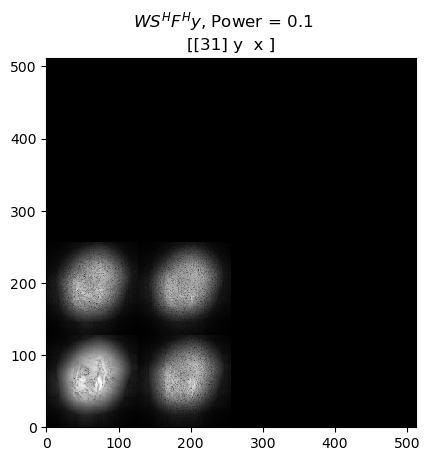

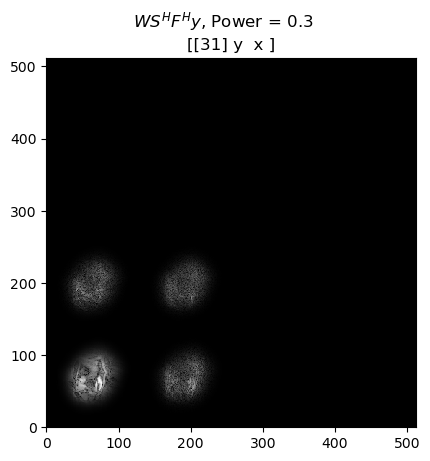

In [10]:
W = sp.linop.Wavelet(img_shape, wave_name='haar', level=8)
wav = W * nufft_sense_norm
pl.ImagePlot(np.abs(wav)**0.05, title=r'$W S^H F^H y$, Power = 0.05')

# stronger enhancement
pl.ImagePlot(np.abs(wav)**0.1, title="$W S^H F^H y$, Power = 0.1")
# recon_plot_helpers.plot_recons_all_axes(np.abs(wav)**0.1, title="Enhanced view, $W S^H F^H y$")

pl.ImagePlot(np.abs(wav)**0.3, title="$W S^H F^H y$, Power = 0.3")

In [11]:
# W = sp.linop.Wavelet(img_shape, wave_name='db4', level=4)
# wav = W * nufft_sense_norm
# pl.ImagePlot(np.abs(wav)**0.1, title=r'$W S^H F^H y$, Power = 0.05')

# # stronger enhancement
# pl.ImagePlot(np.abs(wav)**0.3, title="$W S^H F^H y$, Power = 0.1")
# # recon_plot_helpers.plot_recons_all_axes(np.abs(wav)**0.1, title="Enhanced view, $W S^H F^H y$")

# pl.ImagePlot(np.abs(wav)**0.9, title="$W S^H F^H y$, Power = 0.3")

In [12]:
# Wavelet coefficient distribution
wav_norm = W * nufft_sense_norm
print(f'WAVELET COEFF DISTRIBUTION (Normalized)')
print("="*60)
print(f"Wav coeff percentiles: {np.percentile(np.abs(wav_norm), [25, 50, 75, 90, 95, 99])}")
print(f"Fraction < 1e-10: {np.mean(np.abs(wav_norm) < 1e-10)}")
print(f"Fraction > 0.1: {np.mean(np.abs(wav_norm) > 0.1)}")

WAVELET COEFF DISTRIBUTION (Normalized)
Wav coeff percentiles: [1.29366680e-13 2.58266824e-09 1.81047663e-04 6.99666874e-03
 1.69999144e-02 6.91856992e-02]
Fraction < 1e-10: 0.42591310316516506
Fraction > 0.1: 0.006120189543693296


In [31]:
check_data(wav_norm)

Step X - Shape: (62, 512, 512)
  Real range: [-28.762816711941408, 68.29255574649099]
  Imag range: [0.0, 0.0]
  Magnitude range: [0.0, 68.29255574649099]
  Dtype: float64
  Any NaN: False, Any Inf: False


### A Linop

In [13]:
A = F * S * W.H
print(f'A = {A}')

A = <[15, 22623, 512]x[62, 512, 512]> NUFFT * Multiply * InverseWavelet Linop>


### Prox

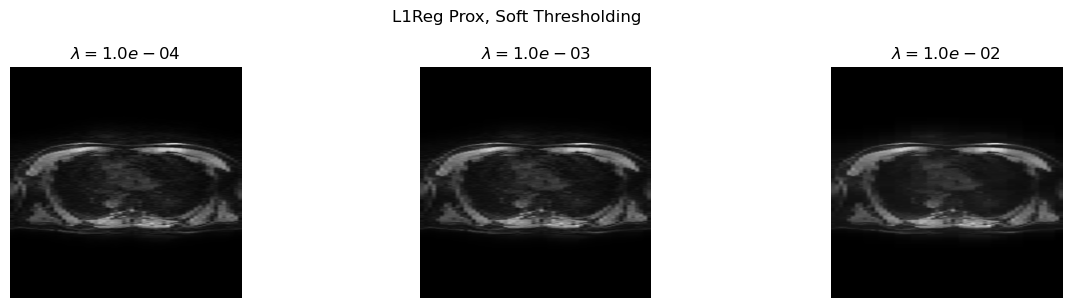

In [39]:
import matplotlib.pyplot as plt

def plot_proxg_lams(W, lams, wav, power=0.08):
    """ Plot an array of lams given wavelet transform"""
    fig, axes = plt.subplots(1, len(lams), figsize=(15, 3))

    for i, lam in enumerate(lams):
        proxg = sp.prox.L1Reg(wav.shape, lam)
        wav_thresh = proxg(2, wav)
        img_from_wav = W.H * wav_thresh
        # axes[i].imshow(np.abs(wav_thresh[30, :, :])**power, cmap='gray')
        # axes[i].imshow(np.abs(img_from_wav[:, 256, :]), cmap='gray', aspect=512/58)
        axes[i].imshow(np.rot90(np.abs(img_from_wav[:, 256, :]), k=1), cmap='gray', aspect=58/512)
        axes[i].set_title(rf'$\lambda = {lam:.1e}$')
        axes[i].axis('off')
    fig.suptitle(f'L1Reg Prox, Soft Thresholding', y=1.07)



# lambdas_unnorm = [1e-22, 1e-23, 1e-24, 1e-25, 1e-35]
# lambdas_norm = [1e-6, 1e-4, 5e-3, 0.001, 0.005, 0.01, 0.05]
lambdas_norm = [1e-4, 1e-3, 1e-2]
wav_norm_comp = wav_norm.astype(complex)
plot_proxg_lams(W, lambdas_norm, wav_norm_comp)


Define a new k-space based on these normalized images

In [15]:
lam = 5e-3
wav_norm = W * nufft_sense_norm
# proxg = sp.prox.L1Reg(wav_norm.shape, lam)
# wav_thresh = proxg(1, wav)
# img_from_wav = W.H * wav_thresh

ksp_from_wav_norm = A * wav_norm

In [16]:
print(f'ksp_from_wav_norm.shape = {ksp_from_wav_norm.shape}')

ksp_from_wav_norm.shape = (15, 22623, 512)


### Alg

/home/lilianae/mambaforge/envs/jointrecon_env_backup_new/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 8 is too high: all coefficients will experience boundary effects.
  warnings.warn(


Gradient max: 0.0
Lambda: 0.001
Alpha: 0.3
wav_init_norm stats:
Step X - Shape: (62, 512, 512)
  Real range: [-28.762816711941408, 68.29255574649099]
  Imag range: [0.0, 0.0]
  Magnitude range: [0.0, 68.29255574649099]
  Dtype: complex128
  Any NaN: False, Any Inf: False
updated alg.x stats:
Step X - Shape: (62, 512, 512)
  Real range: [-28.76251671194141, 68.292255746491]
  Imag range: [0.0, 0.0]
  Magnitude range: [0.0, 68.292255746491]
  Dtype: complex128
  Any NaN: False, Any Inf: False
L1WaveletRecon, Iteration=1updated alg.x stats:
Step X - Shape: (62, 512, 512)
  Real range: [-28.721485241790575, 68.06801353815153]
  Imag range: [0.0, 0.0]
  Magnitude range: [0.0, 68.06801353815153]
  Dtype: complex128
  Any NaN: False, Any Inf: False
L1WaveletRecon, Iteration=2updated alg.x stats:
Step X - Shape: (62, 512, 512)
  Real range: [-28.102808120202912, 63.65082314932293]
  Imag range: [0.0, 0.0]
  Magnitude range: [0.0, 63.65082314932293]
  Dtype: complex128
  Any NaN: False, Any Inf

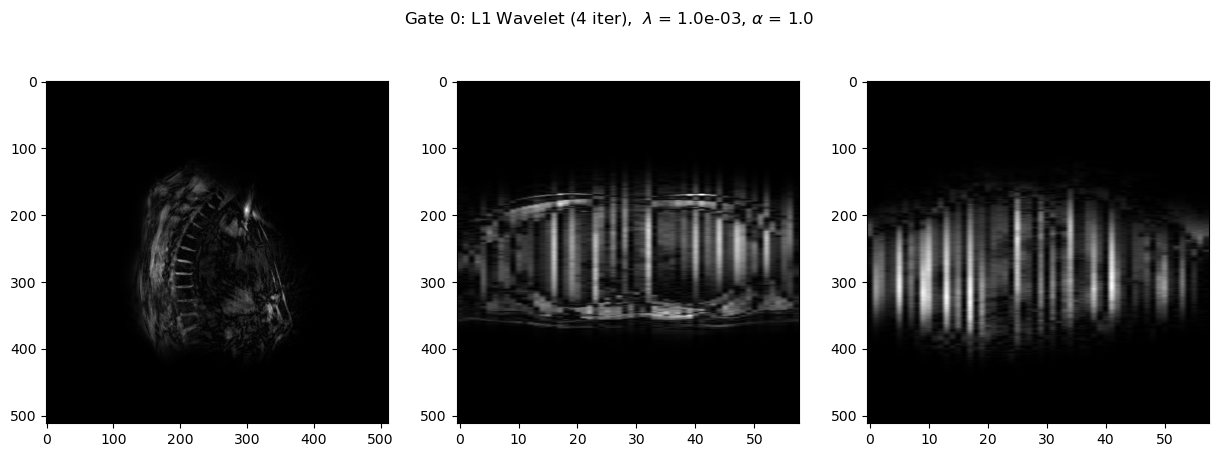

Successfully saved as alg_x_4iters_l1_alpha0.3_lam1e-3.pkl


In [34]:
wav_init_norm = W * nufft_sense_norm
wav_init_norm = wav_init_norm.astype(complex)

def gradf(x):
    return W * np.abs(S.H * F.H * (A * x - ksp_from_wav_norm))

# Test out gradient on initial wav
grad_test = gradf(wav_init_norm)
grad_scale = np.max(np.abs(grad_test))
print(f"Gradient max: {grad_scale}")

lamda = 1e-3
print(f"Lambda: {lamda}")

proxg = sp.prox.L1Reg(wav_init_norm.shape, lamda)

# suggested alpha
alpha = 0.3
print(f"Alpha: {alpha}")

max_iter = 4
alg = sp.alg.GradientMethod(gradf, wav_init_norm, alpha, proxg=proxg, max_iter=max_iter)

print(f'wav_init_norm stats:')
check_data(wav_init_norm)

while not alg.done():
    alg.update()
    print(f'updated alg.x stats:')
    check_data(alg.x)
    print('\rL1WaveletRecon, Iteration={}'.format(alg.iter), end='')


result_img = W.H(alg.x)
recon_plot_helpers.plot_recons_all_axes(np.abs(result_img), title=rf'Gate 0: L1 Wavelet ({max_iter} iter),  $\lambda$ = {lamda:.1e}, $\alpha$ = 0.3')
save_data_helpers.write_pickle(alg.x, 'alg_x_4iters_l1_alpha0.3_lam1e-3.pkl')

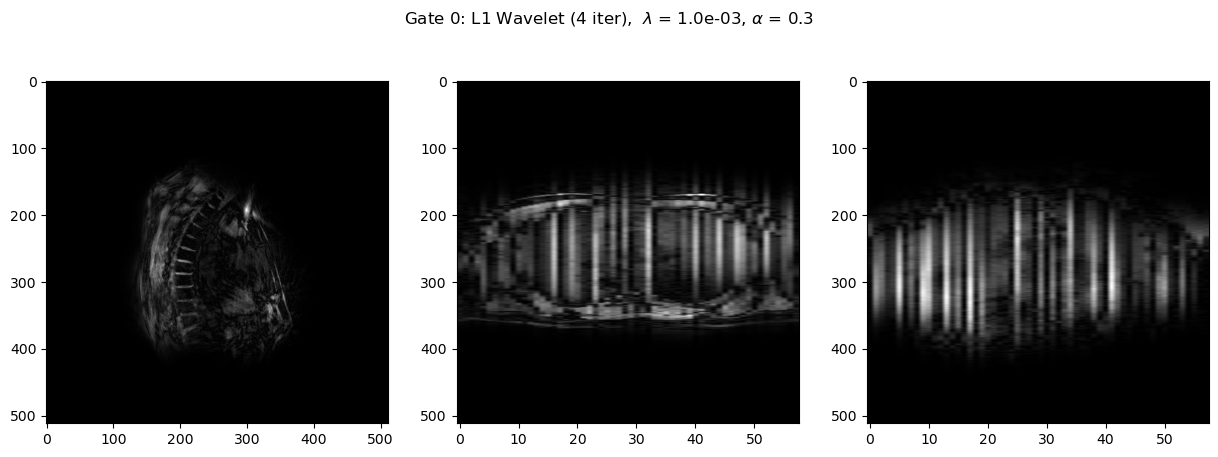

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [35]:
recon_plot_helpers.plot_recons_all_axes(np.abs(result_img), title=rf'Gate 0: L1 Wavelet ({max_iter} iter),  $\lambda$ = {lamda:.1e}, $\alpha$ = 0.3')

In [27]:
print(alg.x.shape)
save_data_helpers.write_pickle(alg.x, 'alg_x_3iters_l1_alpha0.1_lam1e-3.pkl')

(62, 512, 512)
Successfully saved as alg_x_3iters_l1_alpha0.1_lam1e-3.pkl


In [30]:
result = alg.x
init = wav_init_norm

check_data(alg.x)
check_data(wav_init_norm)

Step X - Shape: (62, 512, 512)
  Real range: [-28.73307896638584, 68.0910293290251]
  Imag range: [0.0, 0.0]
  Magnitude range: [0.0, 68.0910293290251]
  Dtype: complex128
  Any NaN: False, Any Inf: False
Step X - Shape: (62, 512, 512)
  Real range: [-28.73307896638584, 68.0910293290251]
  Imag range: [0.0, 0.0]
  Magnitude range: [0.0, 68.0910293290251]
  Dtype: complex128
  Any NaN: False, Any Inf: False


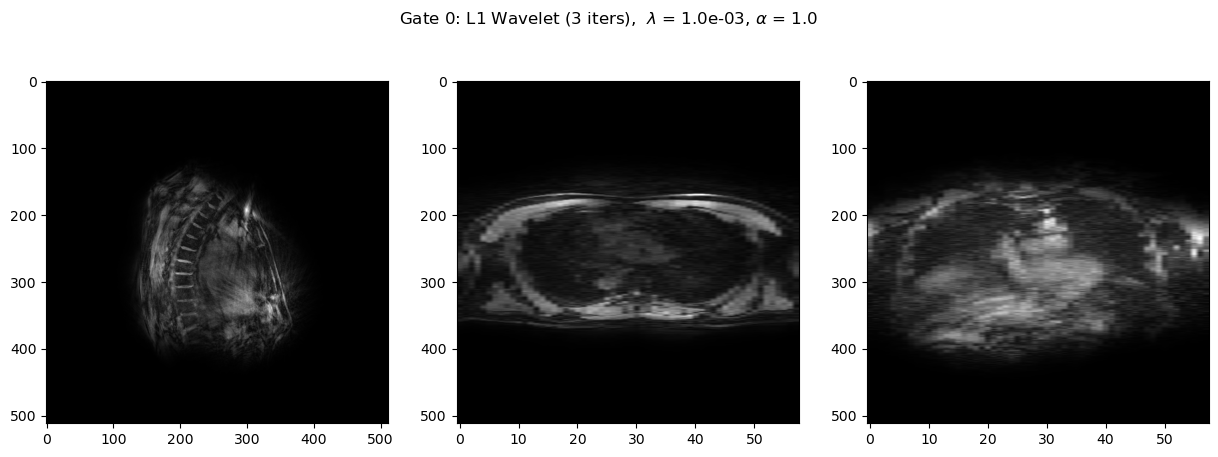

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [22]:
recon_plot_helpers.plot_recons_all_axes(np.abs(result_img), title=rf'Gate 0: L1 Wavelet (3 iters),  $\lambda$ = {lamda:.1e}, $\alpha$ = 1.0')

In [23]:
save_data_helpers.write_pickle(result_img, 'result_img_l1_3iters_lam1e-3_alpha0.1.pkl')

Successfully saved as result_img_l1_3iters_lam1e-3_alpha0.1.pkl


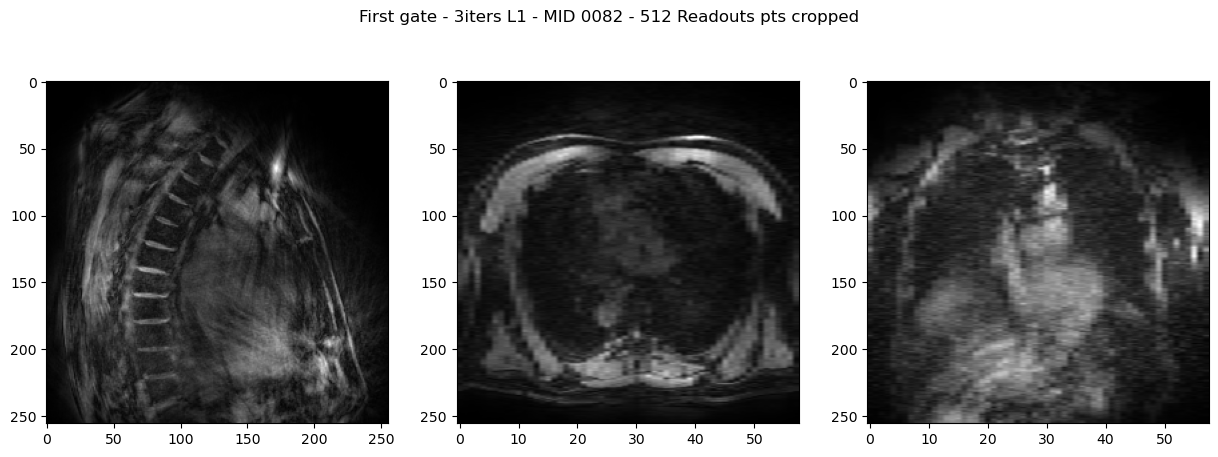

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [25]:
# Center crop from 512x512 to 256x256
# Calculate the starting indices for the crop
start_h = (512 - 256) // 2  # 128
start_w = (512 - 256) // 2  # 128

# Crop along the last two dimensions
gate_image_cropped = result_img[:, start_h:start_h+256, start_w:start_w+256]

recon_plot_helpers.plot_recons_all_axes(gate_image_cropped, title=f"First gate - 3iters L1 - MID 0082 - 512 Readouts pts cropped")

In [ ]:
print(f'{alg.iter:.1f}')